In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [4]:
log_file_path = 'HDFS_2k.log'

with open(log_file_path, 'r', encoding='utf-8', errors='ignore') as f:
    logs= f.readlines()

print(f"Total log lines: {len(logs)}")
print(f"\nFirst 10 lines:")

for i, line in enumerate(logs[:10], 1):
    print(f"{i:3d}. {line.strip()}")



Total log lines: 2000

First 10 lines:
  1. 081109 203615 148 INFO dfs.DataNode$PacketResponder: PacketResponder 1 for block blk_38865049064139660 terminating
  2. 081109 203807 222 INFO dfs.DataNode$PacketResponder: PacketResponder 0 for block blk_-6952295868487656571 terminating
  3. 081109 204005 35 INFO dfs.FSNamesystem: BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.251.73.220:50010 is added to blk_7128370237687728475 size 67108864
  4. 081109 204015 308 INFO dfs.DataNode$PacketResponder: PacketResponder 2 for block blk_8229193803249955061 terminating
  5. 081109 204106 329 INFO dfs.DataNode$PacketResponder: PacketResponder 2 for block blk_-6670958622368987959 terminating
  6. 081109 204132 26 INFO dfs.FSNamesystem: BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.251.43.115:50010 is added to blk_3050920587428079149 size 67108864
  7. 081109 204324 34 INFO dfs.FSNamesystem: BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.251.203.80:50010 is added to blk_788894

In [5]:
# Basic log structure analysis

line_lengths = [len(line.strip()) for line in logs if line.strip()]
print(f"Average line length: {np.mean(line_lengths):.2f} characters")
print(f"Min line length: {min(line_lengths)} characters")
print(f"Max line length: {max(line_lengths)} characters")

empty_lines = sum(1 for line in logs if not line.strip())
print(f"\nEmpty lines: {empty_lines}")


Average line length: 141.92 characters
Min line length: 93 characters
Max line length: 2520 characters

Empty lines: 0


In [6]:
# Parse log entries to understand structure
def parse_log_line(line):
    
    line = line.strip()
    if not line:
        return None
    
    pattern = r'^(\d{6})\s+(\d{6})\s+(\d+)\s+(\w+)\s+(.+?):\s+(.+)$'
    match = re.match(pattern, line)
    
    if match:
        date_part, time_part, num, level, component, message = match.groups()
        return {
            'date': date_part,
            'time': time_part,
            'log_level': level,
            'component': component,
            'message': message
        }
    return None

# Parse all logs
parsed_logs = []
for line in logs:
    parsed = parse_log_line(line)
    if parsed:
        parsed_logs.append(parsed)

# Convert to DataFrame
df = pd.DataFrame(parsed_logs)
print('Shape :',df.shape)
df.head(10)


Shape : (1999, 5)


,date,time,log_level,component,message
0,081109,203615,INFO,dfs.DataNode$PacketResponder,PacketResponder 1 for block blk_38865049064139...
1,081109,203807,INFO,dfs.DataNode$PacketResponder,PacketResponder 0 for block blk_-6952295868487...
2,081109,204005,INFO,dfs.FSNamesystem,BLOCK* NameSystem.addStoredBlock: blockMap upd...
3,081109,204015,INFO,dfs.DataNode$PacketResponder,PacketResponder 2 for block blk_82291938032499...
4,081109,204106,INFO,dfs.DataNode$PacketResponder,PacketResponder 2 for block blk_-6670958622368...
5,081109,204132,INFO,dfs.FSNamesystem,BLOCK* NameSystem.addStoredBlock: blockMap upd...
6,081109,204324,INFO,dfs.FSNamesystem,BLOCK* NameSystem.addStoredBlock: blockMap upd...
7,081109,204453,INFO,dfs.FSNamesystem,BLOCK* NameSystem.addStoredBlock: blockMap upd...
8,081109,204525,INFO,dfs.DataNode$PacketResponder,PacketResponder 2 for block blk_57249283928729...
9,081109,204655,INFO,dfs.DataNode$PacketResponder,Received block blk_35875081onder: 40051953248 ...


In [7]:
messages = []
for line in logs:
    parsed = parse_log_line(line)
    if parsed:
        messages.append(parsed["message"])

messages

['PacketResponder 1 for block blk_38865049064139660 terminating',
 'PacketResponder 0 for block blk_-6952295868487656571 terminating',
 'BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.251.73.220:50010 is added to blk_7128370237687728475 size 67108864',
 'PacketResponder 2 for block blk_8229193803249955061 terminating',
 'PacketResponder 2 for block blk_-6670958622368987959 terminating',
 'BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.251.43.115:50010 is added to blk_3050920587428079149 size 67108864',
 'BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.251.203.80:50010 is added to blk_7888946331804732825 size 67108864',
 'BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.250.11.85:50010 is added to blk_2377150260128098806 size 67108864',
 'PacketResponder 2 for block blk_572492839287299681 terminating',
 'Received block blk_35875081onder: 40051953248 of size 67108864 from /10.251.42.84',
 'Receiving block blk_5792489080791696128 src: /10.251.30.6:33145 dest: 

In [8]:
# Basic statistics

print(f"Total log entries: {len(df)}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Time range: {df['time'].min()} to {df['time'].max()}")

print(f"\n Log Levels Distribution")
log_level_counts = df['log_level'].value_counts()
print(log_level_counts)

print(f"\nPercentage distribution:")
print((log_level_counts / len(df) * 100).round(2))


Total log entries: 1999
Date range: 081109 to 081111
Time range: 000037 to 235951

 Log Levels Distribution
log_level
INFO    1919
WARN      80
Name: count, dtype: int64

Percentage distribution:
log_level
INFO    96.0
WARN     4.0
Name: count, dtype: float64


In [9]:
# Component analysis

print(f"Total unique components: {df['component'].nunique()}")
print(f"\nMost frequent components:")
component_counts = df['component'].value_counts()
print(component_counts)



Total unique components: 6

Most frequent components:
component
dfs.FSNamesystem                659
dfs.DataNode$PacketResponder    602
dfs.DataNode$DataXceiver        454
dfs.FSDataset                   263
dfs.DataBlockScanner             20
dfs.DataNode                      1
Name: count, dtype: int64


In [10]:
# Message analysis
df['message_length'] = df['message'].apply(len)
df['word_count'] = df['message'].apply(lambda x: len(x.split()))

print("Message length statistics:")
print(df['message_length'].describe())

print("\nWord count statistics:")
print(df['word_count'].describe())


Message length statistics:
count    1999.000000
mean       95.439720
std        78.462071
min        49.000000
25%        75.000000
50%        93.000000
75%       107.000000
max      2480.000000
Name: message_length, dtype: float64

Word count statistics:
count    1999.000000
mean        7.442721
std         3.727800
min         4.000000
25%         6.000000
50%         7.000000
75%         9.000000
max       105.000000
Name: word_count, dtype: float64


In [11]:
df.head()

,date,time,log_level,component,message,message_length,word_count
0,081109,203615,INFO,dfs.DataNode$PacketResponder,PacketResponder 1 for block blk_38865049064139...,61,6
1,081109,203807,INFO,dfs.DataNode$PacketResponder,PacketResponder 0 for block blk_-6952295868487...,64,6
2,081109,204005,INFO,dfs.FSNamesystem,BLOCK* NameSystem.addStoredBlock: blockMap upd...,121,11
3,081109,204015,INFO,dfs.DataNode$PacketResponder,PacketResponder 2 for block blk_82291938032499...,63,6
4,081109,204106,INFO,dfs.DataNode$PacketResponder,PacketResponder 2 for block blk_-6670958622368...,64,6


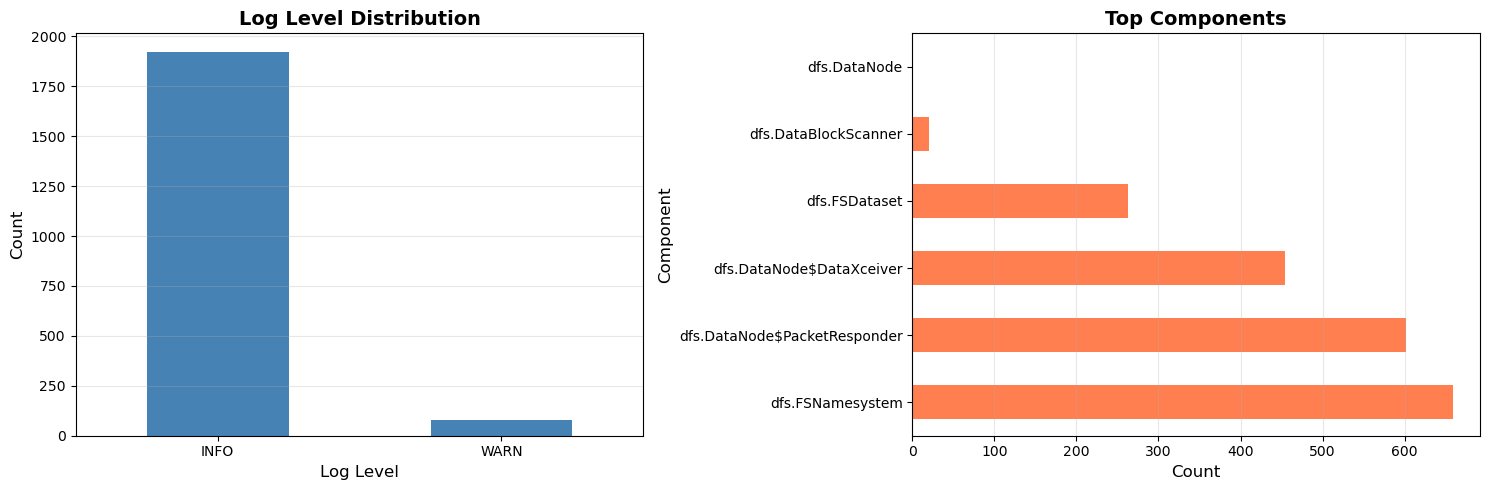

In [12]:
# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Log Level Distribution
log_level_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Log Level Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Log Level', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(axis='y', alpha=0.3)

# 2. Top Components
component_counts.head(10).plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Top Components', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Count', fontsize=12)
axes[1].set_ylabel('Component', fontsize=12)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('eda_visualizations.png', dpi=150, bbox_inches='tight')

plt.show()


In [13]:
df["date"] = df["date"].astype(str)
df["time"] = df["time"].astype(str)
df["datetime_str"] = df["date"] + df["time"]
df["timestamp"] = pd.to_datetime(
    df["datetime_str"],
    format="%m%d%y%H%M%S"
)
df.drop(columns=["datetime_str","date","time"], inplace=True)
timestamp_col = df.pop("timestamp")
df.insert(0, "timestamp", timestamp_col)
df.drop(columns=["message_length","word_count"], inplace=True)

In [14]:
df

,timestamp,log_level,component,message
0,2009-08-11 20:36:15,INFO,dfs.DataNode$PacketResponder,PacketResponder 1 for block blk_38865049064139...
1,2009-08-11 20:38:07,INFO,dfs.DataNode$PacketResponder,PacketResponder 0 for block blk_-6952295868487...
2,2009-08-11 20:40:05,INFO,dfs.FSNamesystem,BLOCK* NameSystem.addStoredBlock: blockMap upd...
3,2009-08-11 20:40:15,INFO,dfs.DataNode$PacketResponder,PacketResponder 2 for block blk_82291938032499...
4,2009-08-11 20:41:06,INFO,dfs.DataNode$PacketResponder,PacketResponder 2 for block blk_-6670958622368...
...,...,...,...,...
1994,2011-08-11 10:16:21,INFO,dfs.DataNode$DataXceiver,Receiving block blk_4198733391373026104 src: /...
1995,2011-08-11 10:17:35,INFO,dfs.DataNode$PacketResponder,Received block blk_-5815145248455404269 of siz...
1996,2011-08-11 10:18:04,INFO,dfs.DataNode$DataXceiver,Receiving block blk_-295306975763175640 src: /...
1997,2011-08-11 10:19:54,INFO,dfs.DataNode$PacketResponder,PacketResponder 0 for block blk_52257196770490...


In [15]:
df.to_csv('logs.csv',index=False)

## EDA Summary

This EDA provides insights into:
- Log structure and format
- Distribution of log levels and components
- Message characteristics (length, word count)
- Time patterns (hourly distribution)
- Common patterns (block IDs, IPs, sizes)

**Next Steps:**
- Based on these insights, we can design appropriate preprocessing steps
- Identify potential anomaly indicators
- Plan feature engineering strategies


#PREPROCESSING

1. **Variable Normalization** #replacing numbers with placeholder
2. **Lowercasing**
3. **Whitespace Cleaning**
4. **Remove special characters**


In [16]:
print(f"\nFirst 5 messages:")
for i, msg in enumerate(messages[:5], 1):
    print(f"{i}. {msg}")


First 5 messages:
1. PacketResponder 1 for block blk_38865049064139660 terminating
2. PacketResponder 0 for block blk_-6952295868487656571 terminating
3. BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.251.73.220:50010 is added to blk_7128370237687728475 size 67108864
4. PacketResponder 2 for block blk_8229193803249955061 terminating
5. PacketResponder 2 for block blk_-6670958622368987959 terminating


In [17]:
def normalize_variables(message):
    
    # Replace block IDs
    message = re.sub(r'blk_[-]?\d+', '<BLOCK_ID>', message)
    
    # Replace IP addresses 
    message = re.sub(r'\b\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}\b', '<IP>', message)
    
    # Replace port numbers
    message = re.sub(r':\d{4,5}', ':<PORT>', message)
    
    # Replace numbers with 6+ digits
    message = re.sub(r'\b\d{6,}\b', '<LARGE_NUM>', message)
    
    # Replace standalone numbers 
    message = re.sub(r'\b\d+\b', '<NUM>', message)
    
    return message

In [18]:
normalized_messages=[]
for msg in messages:
    normalized_messages.append(normalize_variables(msg))

In [19]:
print("Original messages:")
for i, msg in enumerate(messages[:1500], 1):
    print(f"{i}. {msg}")

print("\nNormalized messages:")
for i, msg in enumerate(normalized_messages[:4], 1):
    print(f"{i}. {msg}")

Original messages:
1. PacketResponder 1 for block blk_38865049064139660 terminating
2. PacketResponder 0 for block blk_-6952295868487656571 terminating
3. BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.251.73.220:50010 is added to blk_7128370237687728475 size 67108864
4. PacketResponder 2 for block blk_8229193803249955061 terminating
5. PacketResponder 2 for block blk_-6670958622368987959 terminating
6. BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.251.43.115:50010 is added to blk_3050920587428079149 size 67108864
7. BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.251.203.80:50010 is added to blk_7888946331804732825 size 67108864
8. BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.250.11.85:50010 is added to blk_2377150260128098806 size 67108864
9. PacketResponder 2 for block blk_572492839287299681 terminating
10. Received block blk_35875081onder: 40051953248 of size 67108864 from /10.251.42.84
11. Receiving block blk_5792489080791696128 src: /10.251.30.6:

In [20]:
lowercase_messages=[]
for msg in normalized_messages:
    lowercase_messages.append(msg.lower())

In [21]:
print("Sample lowercase normalized messages:")
for i, msg in enumerate(lowercase_messages[:5], 1):
    print(f"{i}. {msg}")

Sample lowercase normalized messages:
1. packetresponder <num> for block <block_id> terminating
2. packetresponder <num> for block <block_id> terminating
3. block* namesystem.addstoredblock: blockmap updated: <ip>:<port> is added to <block_id> size <large_num>
4. packetresponder <num> for block <block_id> terminating
5. packetresponder <num> for block <block_id> terminating


In [22]:
def clean_whitespace(message):
    message = re.sub(r'\s+', ' ', message)
    
    return message.strip()

In [23]:
cleaned_messages=[]
for msg in lowercase_messages:
    cleaned_messages.append(clean_whitespace(msg))

In [24]:
print("Sample cleaned messages:")
for i, msg in enumerate(cleaned_messages[:5], 1):
    print(f"{i}. {msg}")

Sample cleaned messages:
1. packetresponder <num> for block <block_id> terminating
2. packetresponder <num> for block <block_id> terminating
3. block* namesystem.addstoredblock: blockmap updated: <ip>:<port> is added to <block_id> size <large_num>
4. packetresponder <num> for block <block_id> terminating
5. packetresponder <num> for block <block_id> terminating


In [25]:
cleaned_messages_df = pd.DataFrame({'message': cleaned_messages})
cleaned_messages_df

,message
0,packetresponder <num> for block <block_id> ter...
1,packetresponder <num> for block <block_id> ter...
2,block* namesystem.addstoredblock: blockmap upd...
3,packetresponder <num> for block <block_id> ter...
4,packetresponder <num> for block <block_id> ter...
...,...
1994,receiving block <block_id> src: /<ip>:<port> d...
1995,received block <block_id> of size <large_num> ...
1996,receiving block <block_id> src: /<ip>:<port> d...
1997,packetresponder <num> for block <block_id> ter...


In [26]:
cleaned_messages_df.to_csv('cleaned_messages.csv', index=False)